**HEART DISEASE ANALYSIS AND PREDICTION USING MACHINE LEARNING**

**Import Libraries** 

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

**Load Dataset**

In [16]:
df = pd.read_excel('train.xlsx')

# Preview data
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


**Basic Data Exploration**

In [17]:
# Shape of dataset
df.shape

# Column info
df.info()

# Summary statistics
df.describe()

# Check column names
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

**Missing Value Handling**

In [18]:
# Check missing values
df.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

**Remove Duplicates**

In [19]:
df.duplicated().sum()

df.drop_duplicates(inplace=True)

**Feature Understanding (Target Variable)**

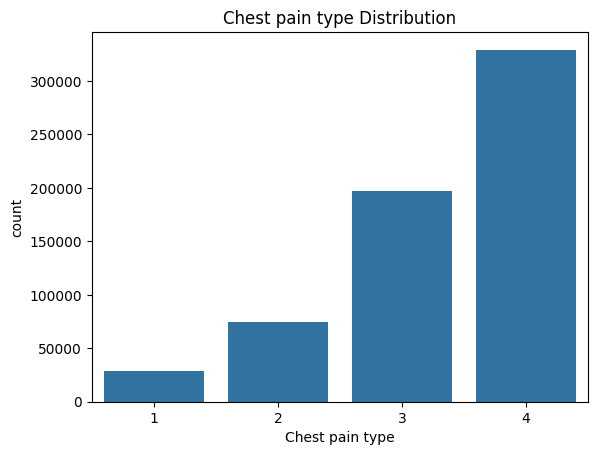

In [20]:
df['Chest pain type'].value_counts()

sns.countplot(x='Chest pain type', data=df)
plt.title("Chest pain type Distribution")
plt.show()

In [21]:
# Check distribution of chest pain types
df['Chest pain type'].value_counts()

Chest pain type
4    329179
3    197278
2     74941
1     28602
Name: count, dtype: int64

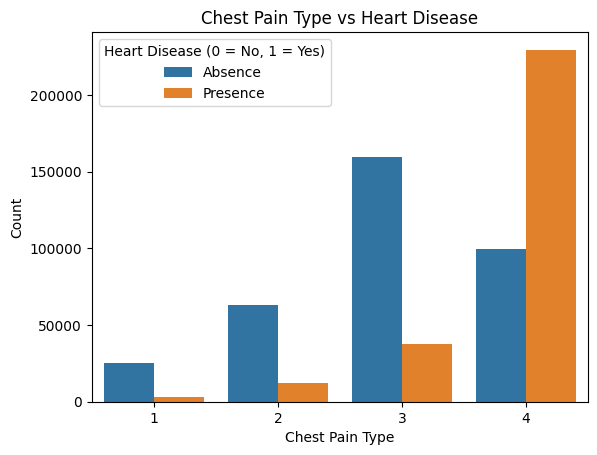

In [27]:
# Visualize chest pain vs heart disease
sns.countplot(x='Chest pain type', hue='Heart Disease', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.legend(title="Heart Disease (0 = No, 1 = Yes)")
plt.show()

**Correaltion Analysis**

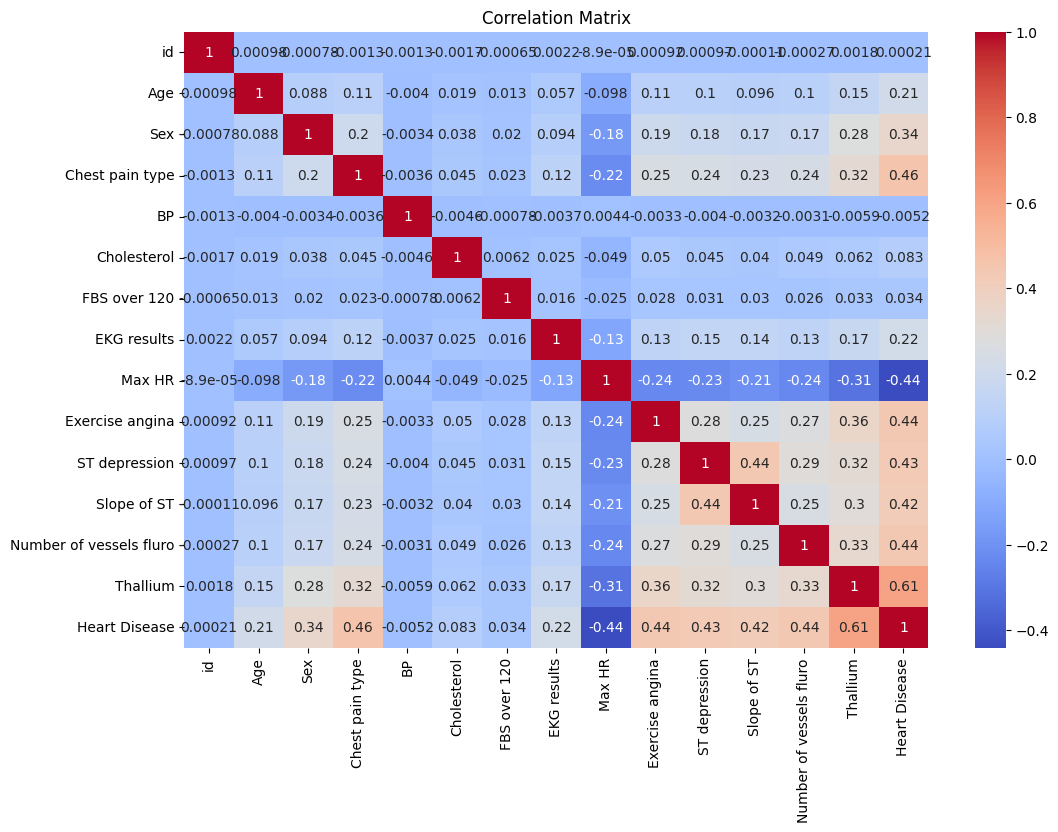

In [32]:
# Encode 'Heart Disease' column to numeric values
df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()